In [1]:
# Multilayer percptom for classification
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
iris= load_iris()
X = iris.data
y = iris.target.reshape(-1,1)
classes = iris.target_names
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2,
random_state=42)

In [9]:
def create_mlp(input_dim, output_dim, hidden_layers, activation='relu'):
    model = Sequential()

    model.add(Dense(hidden_layers[0], input_dim=input_dim, activation=activation))

    for units in hidden_layers[1:]:
        model.add(Dense(units, activation=activation))

    # Output layer
    model.add(Dense(output_dim, activation='softmax'))

    # Compile model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [10]:
hidden_layer_configs = [[8], [16, 8], [32, 16, 8]]
activations = ['relu', 'tanh', 'sigmoid']
for hidden_layers in hidden_layer_configs:
     for activation in activations:
        print(f"\nTesting MLP with hidden_layers={hidden_layers}, activation={activation}")
        model = create_mlp(input_dim=4, output_dim=3, hidden_layers=hidden_layers,activation=activation)
        history = model.fit(X_train, y_train, epochs=50, batch_size=5, verbose=0,validation_split=0.1)
        test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
        print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


Testing MLP with hidden_layers=[8], activation=relu
Test Accuracy: 0.9667, Test Loss: 0.1558

Testing MLP with hidden_layers=[8], activation=tanh
Test Accuracy: 0.9667, Test Loss: 0.2267

Testing MLP with hidden_layers=[8], activation=sigmoid
Test Accuracy: 0.9333, Test Loss: 0.4078

Testing MLP with hidden_layers=[16, 8], activation=relu
Test Accuracy: 0.9667, Test Loss: 0.0703

Testing MLP with hidden_layers=[16, 8], activation=tanh
Test Accuracy: 0.9667, Test Loss: 0.0751

Testing MLP with hidden_layers=[16, 8], activation=sigmoid
Test Accuracy: 0.9333, Test Loss: 0.4270

Testing MLP with hidden_layers=[32, 16, 8], activation=relu
Test Accuracy: 1.0000, Test Loss: 0.0364

Testing MLP with hidden_layers=[32, 16, 8], activation=tanh
Test Accuracy: 1.0000, Test Loss: 0.0421

Testing MLP with hidden_layers=[32, 16, 8], activation=sigmoid
Test Accuracy: 0.9333, Test Loss: 0.3087


Text(0, 0.5, 'Accuracy')

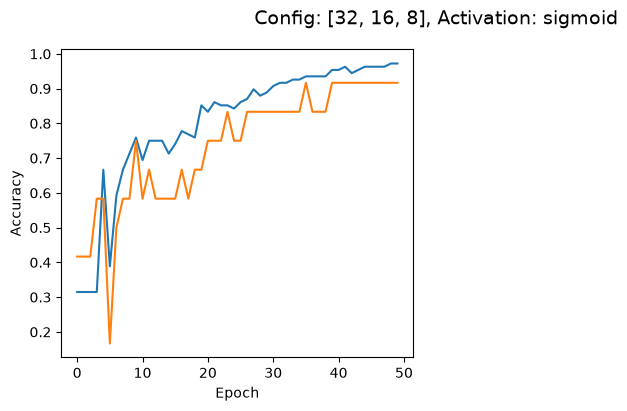

In [11]:
# Plot accuracy and loss
plt.figure(figsize=(10, 4))
plt.suptitle(f"Config: {hidden_layers}, Activation: {activation}", fontsize=14)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

C:\Users\VARNEKA K\AppData\Local\Temp\ipykernel_3020\1218536080.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


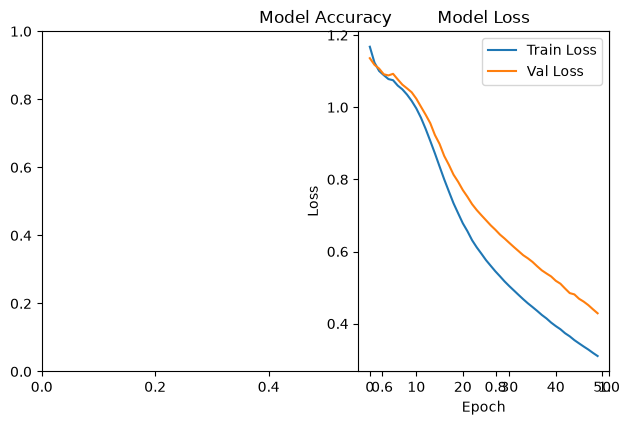

In [12]:
plt.title('Model Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.tight_layout()
plt.show()